In [2]:
import torch
print(torch.__version__, torch.cuda.is_available())


2.6.0+cu124 True


In [4]:
# Install latest detectron2 (works with torch 2.6.0 + CUDA 12.4)
!pip install -U 'git+https://github.com/facebookresearch/detectron2.git'

# Restart runtime after this if you're using Colab or Jupyter


  Cloning https://github.com/facebookresearch/detectron2.git to /tmp/pip-req-build-w6btt_75
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/detectron2.git /tmp/pip-req-build-w6btt_75
  Resolved https://github.com/facebookresearch/detectron2.git to commit 0eeec6d5c0ae7e29028c3b976379f70c755209c4
  Preparing metadata (setup.py) ... done


In [1]:
# Basic imports
import torch
import torchvision
import cv2
import os
import random
import numpy as np
import matplotlib.pyplot as plt

# Detectron2 imports
from detectron2.utils.logger import setup_logger
setup_logger()

from detectron2 import model_zoo
from detectron2.engine import DefaultPredictor, DefaultTrainer
from detectron2.config import get_cfg
from detectron2.utils.visualizer import Visualizer
from detectron2.data import MetadataCatalog, DatasetCatalog
from detectron2.data.datasets import register_coco_instances


In [4]:
zip_path = "/content/MASK-1.v1i.coco-segmentation.zip"
import zipfile
import os

extract_path = "/content/plastic_dataset"  # Where to extract the dataset

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("✅ Unzipped at:", extract_path)


✅ Unzipped at: /content/plastic_dataset


In [5]:
dataset_path = "/content/plastic_dataset"  # Change if different
train_json = os.path.join(dataset_path, "train", "_annotations.coco.json")
valid_json = os.path.join(dataset_path, "valid", "_annotations.coco.json")

register_coco_instances("plastic_train", {}, train_json, os.path.join(dataset_path, "train"))
register_coco_instances("plastic_val", {}, valid_json, os.path.join(dataset_path, "valid"))


WARNING [07/07 08:01:57 d2.data.datasets.coco]: 
Category ids in annotations are not in [1, #categories]! We'll apply a mapping for you.

[07/07 08:01:57 d2.data.datasets.coco]: Loaded 116 images in COCO format from /content/plastic_dataset/train/_annotations.coco.json


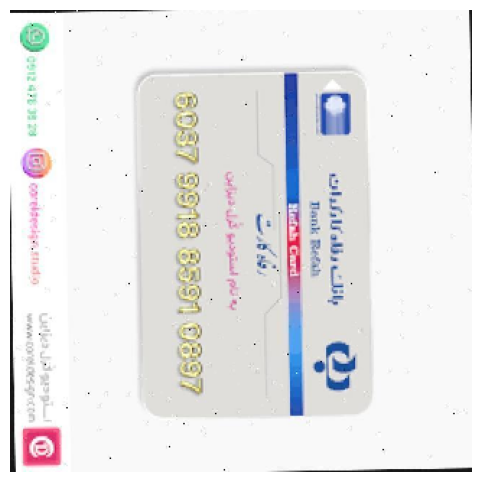

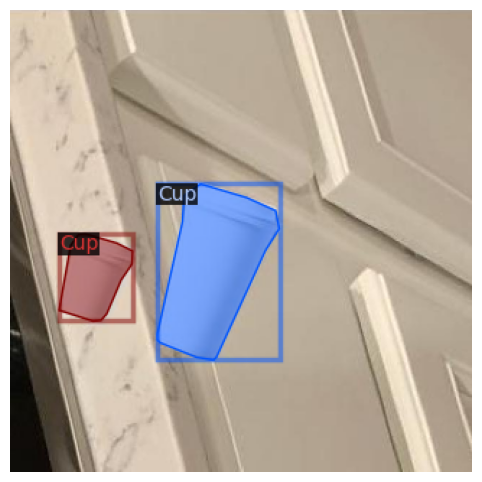

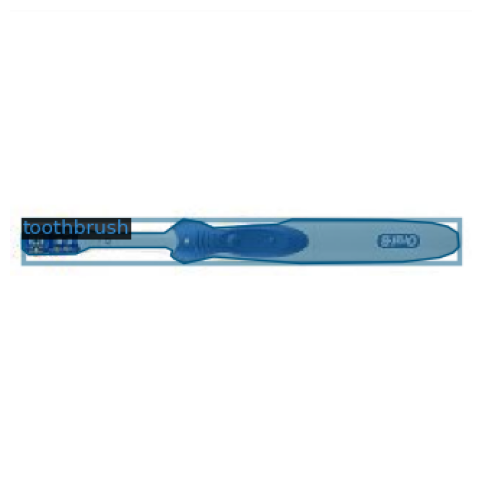

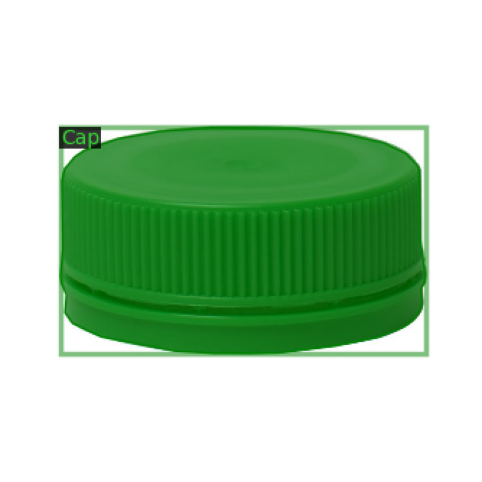

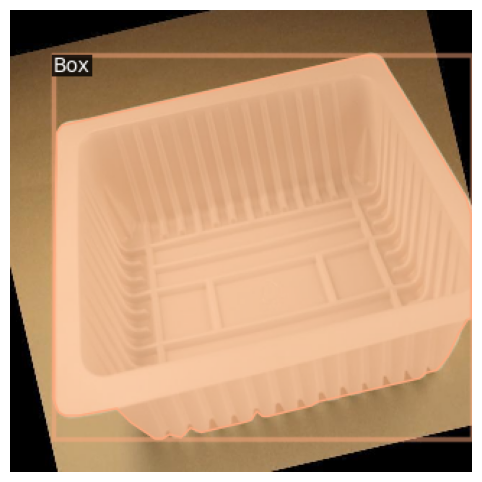

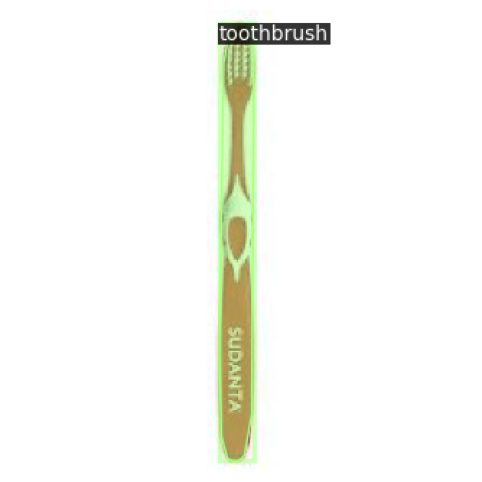

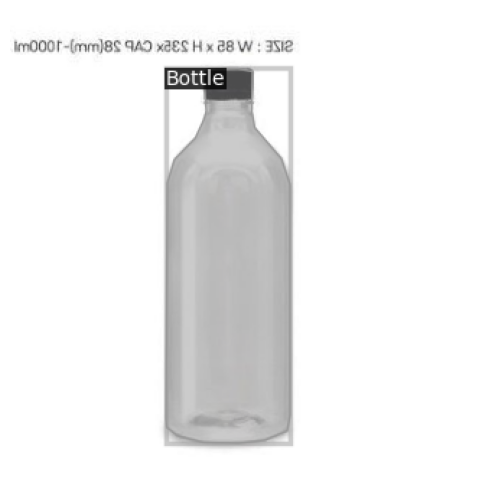

In [7]:
metadata = MetadataCatalog.get("plastic_train")
dataset_dicts = DatasetCatalog.get("plastic_train")

for d in random.sample(dataset_dicts, 7):
    img = cv2.imread(d["file_name"])
    visualizer = Visualizer(img[:, :, ::-1], metadata=metadata, scale=0.5)
    vis = visualizer.draw_dataset_dict(d)

    plt.figure(figsize=(10, 6))
    plt.imshow(vis.get_image())
    plt.axis('off')
    plt.show()


In [8]:
cfg = get_cfg()
cfg.merge_from_file(model_zoo.get_config_file("COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x.yaml"))

cfg.DATASETS.TRAIN = ("plastic_train",)
cfg.DATASETS.TEST = ("plastic_val",)
cfg.DATALOADER.NUM_WORKERS = 2

cfg.MODEL.WEIGHTS = model_zoo.get_checkpoint_url("COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x.yaml")
cfg.SOLVER.IMS_PER_BATCH = 2
cfg.SOLVER.BASE_LR = 0.00025
cfg.SOLVER.MAX_ITER = 2000
cfg.SOLVER.STEPS = []

cfg.MODEL.ROI_HEADS.BATCH_SIZE_PER_IMAGE = 128
cfg.MODEL.ROI_HEADS.NUM_CLASSES = 8  # Change if needed

cfg.OUTPUT_DIR = "/content/output"
os.makedirs(cfg.OUTPUT_DIR, exist_ok=True)


In [9]:
trainer = DefaultTrainer(cfg)
trainer.resume_or_load(resume=False)
trainer.train()


[07/07 08:02:51 d2.engine.defaults]: Model:
GeneralizedRCNN(
  (backbone): FPN(
    (fpn_lateral2): Conv2d(256, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral3): Conv2d(512, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output3): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral4): Conv2d(1024, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output4): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral5): Conv2d(2048, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output5): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (top_block): LastLevelMaxPool()
    (bottom_up): ResNet(
      (stem): BasicStem(
        (conv1): Conv2d(
          3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False
          (norm): FrozenBatchNorm2d(num_features=64, eps=1e-05)
        )
      )
      (res

model_final_f10217.pkl: 178MB [00:15, 11.2MB/s]                           
roi_heads.box_predictor.bbox_pred.{bias, weight}
roi_heads.box_predictor.cls_score.{bias, weight}
roi_heads.mask_head.predictor.{bias, weight}


[07/07 08:03:07 d2.engine.train_loop]: Starting training from iteration 0


/usr/local/lib/python3.11/dist-packages/torch/functional.py:539: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:3637.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


[07/07 08:03:18 d2.utils.events]:  eta: 0:10:11  iter: 19  total_loss: 3.37  loss_cls: 1.989  loss_box_reg: 0.6118  loss_mask: 0.6895  loss_rpn_cls: 0.005318  loss_rpn_loc: 0.01014    time: 0.3103  last_time: 0.2998  data_time: 0.0151  last_data_time: 0.0042   lr: 4.9953e-06  max_mem: 1769M
[07/07 08:03:29 d2.utils.events]:  eta: 0:10:27  iter: 39  total_loss: 3.184  loss_cls: 1.847  loss_box_reg: 0.67  loss_mask: 0.6841  loss_rpn_cls: 0.001295  loss_rpn_loc: 0.009039    time: 0.3272  last_time: 0.3627  data_time: 0.0078  last_data_time: 0.0049   lr: 9.9902e-06  max_mem: 1770M
[07/07 08:03:35 d2.utils.events]:  eta: 0:10:23  iter: 59  total_loss: 2.681  loss_cls: 1.52  loss_box_reg: 0.4905  loss_mask: 0.6778  loss_rpn_cls: 0.004508  loss_rpn_loc: 0.01496    time: 0.3255  last_time: 0.3229  data_time: 0.0092  last_data_time: 0.0314   lr: 1.4985e-05  max_mem: 1771M
[07/07 08:03:42 d2.utils.events]:  eta: 0:10:23  iter: 79  total_loss: 2.371  loss_cls: 1.092  loss_box_reg: 0.5391  loss_ma

In [11]:
from detectron2.evaluation import COCOEvaluator, inference_on_dataset
from detectron2.data import build_detection_test_loader

# Set up evaluator for validation dataset
evaluator = COCOEvaluator("plastic_val", cfg, False, output_dir="./output/")
val_loader = build_detection_test_loader(cfg, "plastic_val")

# Run evaluation
print(inference_on_dataset(trainer.model, val_loader, evaluator))


WARNING [07/07 08:20:03 d2.evaluation.coco_evaluation]: COCO Evaluator instantiated using config, this is deprecated behavior. Please pass in explicit arguments instead.
WARNING [07/07 08:20:03 d2.data.datasets.coco]: 
Category ids in annotations are not in [1, #categories]! We'll apply a mapping for you.

[07/07 08:20:03 d2.data.datasets.coco]: Loaded 17 images in COCO format from /content/plastic_dataset/valid/_annotations.coco.json
[07/07 08:20:03 d2.data.dataset_mapper]: [DatasetMapper] Augmentations used in inference: [ResizeShortestEdge(short_edge_length=(800, 800), max_size=1333, sample_style='choice')]
[07/07 08:20:03 d2.data.common]: Serializing the dataset using: <class 'detectron2.data.common._TorchSerializedList'>
[07/07 08:20:03 d2.data.common]: Serializing 17 elements to byte tensors and concatenating them all ...
[07/07 08:20:03 d2.data.common]: Serialized dataset takes 0.01 MiB
[07/07 08:20:03 d2.evaluation.evaluator]: Start inference on 17 batches
[07/07 08:20:05 d2.ev

In [14]:
import json
from pycocotools.coco import COCO
from detectron2.data import MetadataCatalog
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np
import os

from detectron2.engine import DefaultPredictor

# Set up predictor
cfg.MODEL.WEIGHTS = os.path.join(cfg.OUTPUT_DIR, "model_final.pth")
cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.5
predictor = DefaultPredictor(cfg)

# Load COCO GT
coco_gt = COCO("/content/plastic_dataset/valid/_annotations.coco.json")

# Class names
class_names = MetadataCatalog.get("plastic_val").thing_classes
id2name = {cat['id']: cat['name'] for cat in coco_gt.loadCats(coco_gt.getCatIds())}
name2idx = {name: i for i, name in enumerate(class_names)}

# Image info
img_ids = coco_gt.getImgIds()

y_true = []
y_pred = []

for img_id in tqdm(img_ids):
    img_info = coco_gt.loadImgs(img_id)[0]
    img_path = os.path.join("/content/plastic_dataset/valid", img_info["file_name"])
    image = cv2.imread(img_path)
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Ground truth labels
    ann_ids = coco_gt.getAnnIds(imgIds=img_id)
    anns = coco_gt.loadAnns(ann_ids)
    for ann in anns:
        gt_label_name = id2name[ann["category_id"]]
        y_true.append(name2idx[gt_label_name])

    # Predict
    outputs = predictor(image_rgb)
    pred_classes = outputs["instances"].pred_classes.cpu().numpy()
    y_pred.extend(pred_classes[:len(anns)])  # Match predicted with GT count (simplified)


[07/07 08:27:21 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from /content/output/model_final.pth ...
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!


100%|██████████| 17/17 [00:01<00:00,  9.66it/s]


In [15]:
cm = confusion_matrix(y_true, y_pred, labels=list(range(len(class_names))))
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()


ValueError: Found input variables with inconsistent numbers of samples: [30, 20]

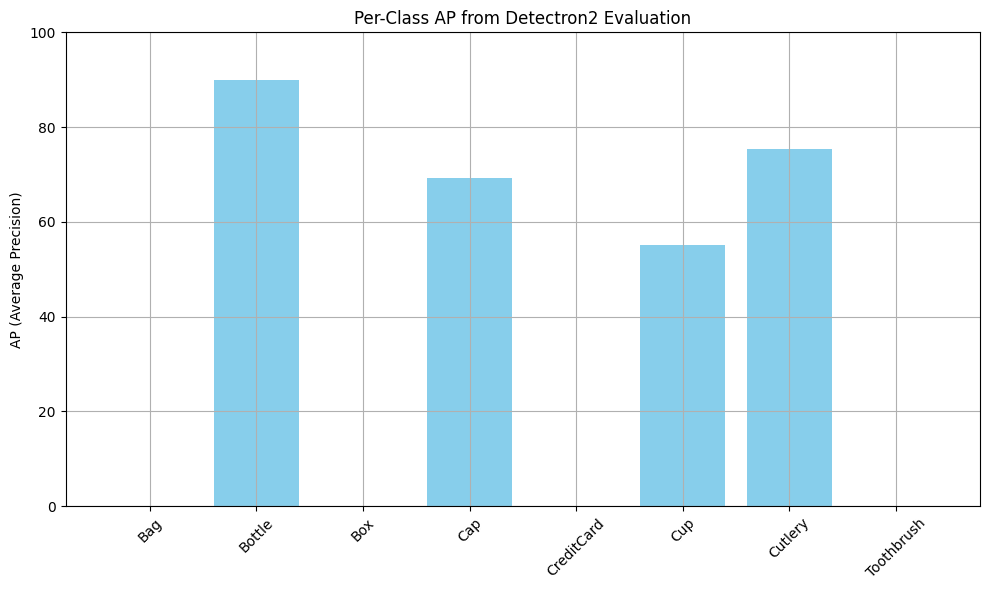

In [16]:
import matplotlib.pyplot as plt

categories = ['Bag', 'Bottle', 'Box', 'Cap', 'CreditCard', 'Cup', 'Cutlery', 'Toothbrush']
ap_scores = [0.0, 90.0, 0.0, 69.3, 0.0, 55.1, 75.4, 0.0]

plt.figure(figsize=(10,6))
plt.bar(categories, ap_scores, color='skyblue')
plt.ylabel("AP (Average Precision)")
plt.title("Per-Class AP from Detectron2 Evaluation")
plt.xticks(rotation=45)
plt.ylim(0, 100)
plt.grid(True)
plt.tight_layout()
plt.show()


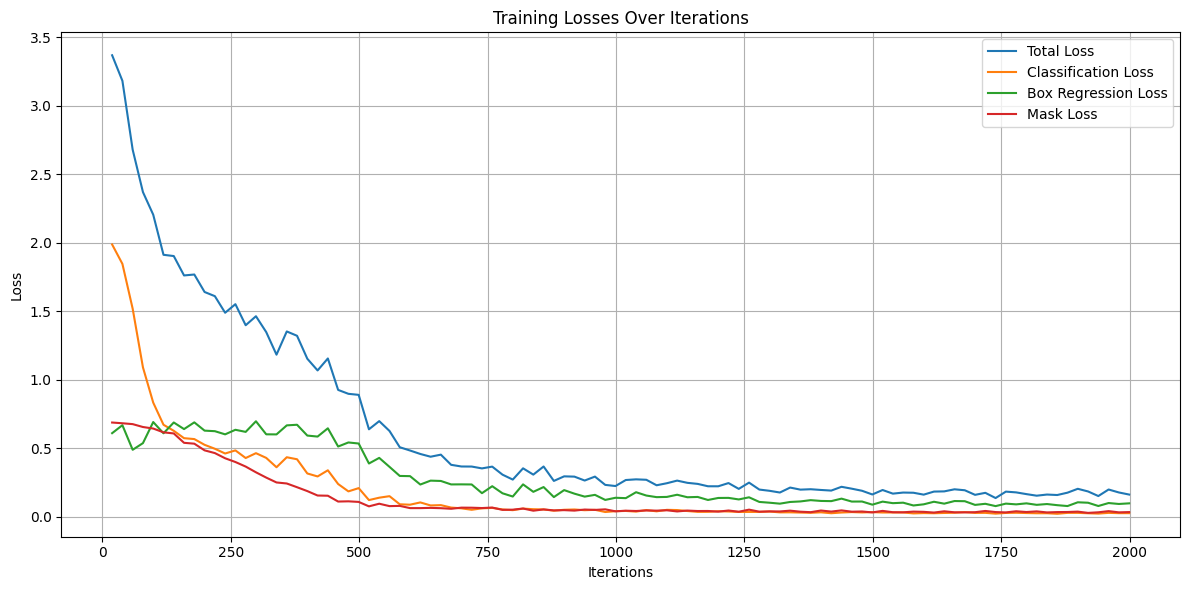

In [17]:
import json
import matplotlib.pyplot as plt

# Load the metrics.json
with open("/content/output/metrics.json", "r") as f:
    metrics = [json.loads(line) for line in f if "total_loss" in line]

# Extract losses
iterations = [m["iteration"] for m in metrics]
total_loss = [m["total_loss"] for m in metrics]
loss_cls = [m["loss_cls"] for m in metrics]
loss_box = [m["loss_box_reg"] for m in metrics]
loss_mask = [m["loss_mask"] for m in metrics]

# Plot
plt.figure(figsize=(12, 6))
plt.plot(iterations, total_loss, label="Total Loss")
plt.plot(iterations, loss_cls, label="Classification Loss")
plt.plot(iterations, loss_box, label="Box Regression Loss")
plt.plot(iterations, loss_mask, label="Mask Loss")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.title("Training Losses Over Iterations")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


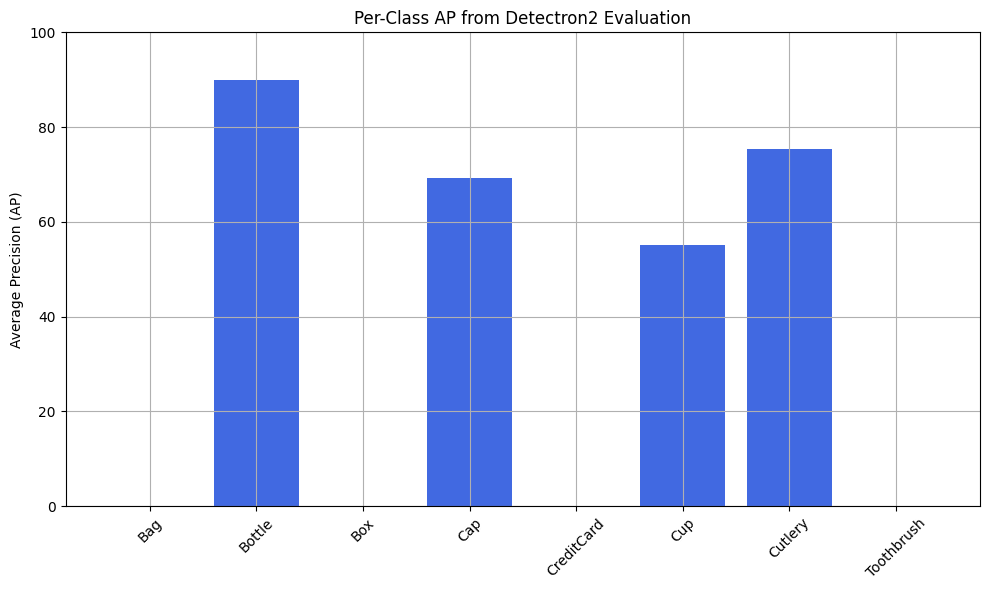

In [19]:
import matplotlib.pyplot as plt

class_names = ['Bag', 'Bottle', 'Box', 'Cap', 'CreditCard', 'Cup', 'Cutlery', 'Toothbrush']
ap_scores = [0, 90, 0, 69.3, 0, 55.1, 75.4, 0]

plt.figure(figsize=(10, 6))
plt.bar(class_names, ap_scores, color='royalblue')
plt.ylabel("Average Precision (AP)")
plt.title("Per-Class AP from Detectron2 Evaluation")
plt.xticks(rotation=45)
plt.ylim(0, 100)
plt.grid(True)
plt.tight_layout()
plt.show()


In [20]:
from IPython.display import display, Markdown

display(Markdown("""
### 📊 COCO Evaluation Summary
| Metric | BBox | Segmentation |
|--------|------|--------------|
| **mAP@[IoU=0.50:0.95]** | 42.7 | 48.3 |
| **AP@IoU=0.50** | 55.7 | 55.7 |
| **AP@IoU=0.75** | 55.7 | 55.7 |
| **AP (Small)** | 52.0 | 46.4 |
| **AP (Medium)** | 35.1 | 41.1 |
| **AP (Large)** | 49.2 | 55.5 |
| **AR (Max Dets=100)** | 49.4 | 54.9 |
"""))



### 📊 COCO Evaluation Summary
| Metric | BBox | Segmentation |
|--------|------|--------------|
| **mAP@[IoU=0.50:0.95]** | 42.7 | 48.3 |
| **AP@IoU=0.50** | 55.7 | 55.7 |
| **AP@IoU=0.75** | 55.7 | 55.7 |
| **AP (Small)** | 52.0 | 46.4 |
| **AP (Medium)** | 35.1 | 41.1 |
| **AP (Large)** | 49.2 | 55.5 |
| **AR (Max Dets=100)** | 49.4 | 54.9 |


[07/07 08:40:07 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from /content/output/model_final.pth ...


roi_heads.box_predictor.bbox_pred.{bias, weight}
roi_heads.box_predictor.cls_score.{bias, weight}
roi_heads.mask_head.predictor.{bias, weight}


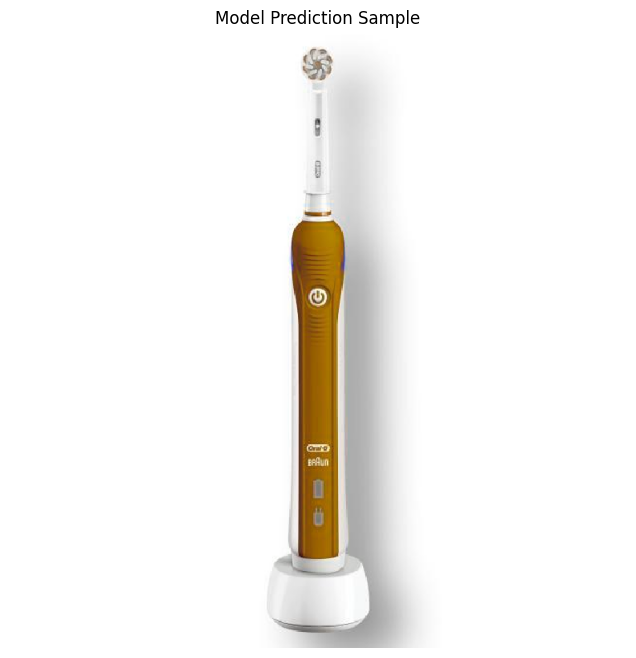

In [29]:
import cv2
import random
from detectron2.utils.visualizer import Visualizer
from detectron2.data import MetadataCatalog
from detectron2.engine import DefaultPredictor
from detectron2.config import get_cfg
from detectron2 import model_zoo

# Setup config
cfg = get_cfg()
cfg.merge_from_file(model_zoo.get_config_file("COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x.yaml"))
cfg.MODEL.WEIGHTS = "/content/output/model_final.pth"
cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.5
cfg.MODEL.ROI_HEADS.NUM_CLASSES = 9
cfg.DATASETS.TEST = ("plastic_valid", )

predictor = DefaultPredictor(cfg)

# Random image from validation folder
img_path = "/content/plastic_dataset/valid/"  # change to your path
img = cv2.imread(random.choice([img_path + f for f in os.listdir(img_path)]))
outputs = predictor(img)

v = Visualizer(img[:, :, ::-1], MetadataCatalog.get(cfg.DATASETS.TEST[0]), scale=1.2)
out = v.draw_instance_predictions(outputs["instances"].to("cpu"))
plt.figure(figsize=(12, 8))
plt.imshow(out.get_image()[:, :, ::-1])
plt.axis('off')
plt.title("Model Prediction Sample")
plt.show()
